# Pathway analysis

In [1]:
import scanpy as sc
import decoupler as dc

# Only needed for processing
import numpy as np
import pandas as pd

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [2]:
comparison = 'middle.vs.old'
experiment = "RNAseq_abundances_adjusted_combat_inmose"


In [3]:
dds = pd.read_csv(f'/home/amore/work/data/{experiment}_{comparison}_DDS.csv',index_col=0)
dds

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
TSPAN6,6.652061e+07,-0.135632,0.136452,-0.993992,0.320227,0.606626
TNMD,1.376112e+05,-4.208728,1.820271,-2.312143,0.020770,0.129159
DPM1,9.614235e+07,-0.113993,0.206214,-0.552788,0.580408,0.753857
SCYL3,1.268802e+07,-1.044279,0.920912,-1.133961,0.256811,0.554243
FIRRM,3.481744e+07,-1.298916,0.583469,-2.226193,0.026001,0.152072
...,...,...,...,...,...,...
C4orf36.1,5.664924e+07,-0.270605,0.288135,-0.939160,0.347649,0.625383
Unnamed: 34327,5.890034e+05,0.744240,1.586006,0.469254,0.638888,0.789295
H2BK1,9.477206e+05,0.507314,1.323758,0.383238,0.701544,0.826746
Unnamed: 34332,5.902246e+06,-1.686947,0.969110,-1.740717,0.081733,0.312195


In [4]:
results_df =dds

In [5]:
### get elbow point
elbow = 3

dds_de = dds[(abs(dds['log2FoldChange'])>elbow) & (dds['padj']<0.01)]
dds_de

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
SEMA3F,1.720695e+06,-3.743393,1.007626,-3.715063,2.031531e-04,2.733627e-03
CFTR,1.715479e+06,-4.146497,1.159413,-3.576374,3.483927e-04,4.383495e-03
MYH16,7.060173e+04,5.626051,1.027215,5.476992,4.326160e-08,1.396810e-06
SARM1,3.847586e+05,-4.708262,1.269728,-3.708086,2.088316e-04,2.792269e-03
CAMKK1,2.716967e+06,-6.991681,1.184862,-5.900840,3.616564e-09,1.414194e-07
...,...,...,...,...,...,...
UPK3BL2,5.339769e+07,-4.248807,0.898820,-4.727096,2.277536e-06,5.021660e-05
Unnamed: 34273,1.676156e+06,-4.449913,1.155180,-3.852138,1.170912e-04,1.684547e-03
Unnamed: 34286,5.194985e+06,-5.015094,1.305054,-3.842825,1.216261e-04,1.741889e-03
PDE4C.1,2.411744e+06,-8.617581,1.123390,-7.671049,1.705949e-14,1.597549e-12


## Get msigdb

In [7]:
msigdb = dc.get_resource('MSigDB')
msigdb# Sort the results by the ranking metric (e.g., log2 fold change)


,genesymbol,collection,geneset
0,MAFF,chemical_and_genetic_perturbations,BOYAULT_LIVER_CANCER_SUBCLASS_G56_DN
1,MAFF,chemical_and_genetic_perturbations,ELVIDGE_HYPOXIA_UP
2,MAFF,chemical_and_genetic_perturbations,NUYTTEN_NIPP1_TARGETS_DN
3,MAFF,immunesigdb,GSE17721_POLYIC_VS_GARDIQUIMOD_4H_BMDC_DN
4,MAFF,chemical_and_genetic_perturbations,SCHAEFFER_PROSTATE_DEVELOPMENT_12HR_UP
...,...,...,...
3838543,PRAMEF22,go_biological_process,GOBP_POSITIVE_REGULATION_OF_CELL_POPULATION_PR...
3838544,PRAMEF22,go_biological_process,GOBP_APOPTOTIC_PROCESS
3838545,PRAMEF22,go_biological_process,GOBP_REGULATION_OF_CELL_DEATH
3838546,PRAMEF22,go_biological_process,GOBP_NEGATIVE_REGULATION_OF_DEVELOPMENTAL_PROCESS


In [8]:
# Filter by hallmark
#msigdb = msigdb[msigdb['collection']=='hallmark']

# Remove duplicated entries
msigdb = msigdb[~msigdb.duplicated(['geneset', 'genesymbol'])]

# Rename
#msigdb.loc[:, 'geneset'] = [name.split('HALLMARK_')[1] for name in msigdb['geneset']]

msigdb

,genesymbol,collection,geneset
0,MAFF,chemical_and_genetic_perturbations,BOYAULT_LIVER_CANCER_SUBCLASS_G56_DN
1,MAFF,chemical_and_genetic_perturbations,ELVIDGE_HYPOXIA_UP
2,MAFF,chemical_and_genetic_perturbations,NUYTTEN_NIPP1_TARGETS_DN
3,MAFF,immunesigdb,GSE17721_POLYIC_VS_GARDIQUIMOD_4H_BMDC_DN
4,MAFF,chemical_and_genetic_perturbations,SCHAEFFER_PROSTATE_DEVELOPMENT_12HR_UP
...,...,...,...
3838543,PRAMEF22,go_biological_process,GOBP_POSITIVE_REGULATION_OF_CELL_POPULATION_PR...
3838544,PRAMEF22,go_biological_process,GOBP_APOPTOTIC_PROCESS
3838545,PRAMEF22,go_biological_process,GOBP_REGULATION_OF_CELL_DEATH
3838546,PRAMEF22,go_biological_process,GOBP_NEGATIVE_REGULATION_OF_DEVELOPMENTAL_PROCESS


In [9]:
set(msigdb["collection"])

{'biocarta_pathways',
 'cancer_gene_neighborhoods',
 'cancer_modules',
 'cell_type_signatures',
 'chemical_and_genetic_perturbations',
 'go_biological_process',
 'go_cellular_component',
 'go_molecular_function',
 'hallmark',
 'human_phenotype_ontology',
 'immunesigdb',
 'kegg_pathways',
 'mirna_targets_legacy',
 'mirna_targets_mirdb',
 'oncogenic_signatures',
 'pid_pathways',
 'positional',
 'reactome_pathways',
 'tf_targets_gtrf',
 'tf_targets_legacy',
 'vaccine_response',
 'wikipathways'}

## GSEA

In [10]:
# Prepare the ranking for GSEA
ranked_genes = results_df[['log2FoldChange']].sort_values(by='log2FoldChange', ascending=False)

# Prepare the ranking for GSEA
gene_list = ranked_genes['log2FoldChange']
gene_list.index = results_df.index  # Ensure the gene symbols are in the index
pd.DataFrame(gene_list)

,log2FoldChange
TSPAN6,12.384376
TNMD,10.115922
DPM1,10.089088
SCYL3,9.379588
FIRRM,9.273909
...,...
C4orf36.1,-43.280851
Unnamed: 34327,-43.280851
H2BK1,-43.280851
Unnamed: 34332,-43.280851


In [11]:

# Run GSEA
enr_gsea = dc.get_gsea_df(
    df=dds,
    stat="stat",
    net=msigdb,
    source='geneset',
    target='genesymbol'
)

# Display the top enrichment results
enr_gsea.head()

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge
0,AAACCAC_MIR140,-0.344816,-1.010954,0.495495,0.925638,103,0.417476,0.363386,SYT6;COL23A1;BACH1;CIT;DHX57;NSD3;KCND2;TAF9B;...
1,AAAGACA_MIR511,-0.299747,-0.891431,0.791000,0.999274,185,0.367568,0.359051,EDEM3;NR4A2;RPS6KL1;KCNMA1;ADGRF5;ANKZF1;RAB22...
2,AAAGGAT_MIR501,-0.294096,-0.866549,0.802803,1.000000,120,0.450000,0.416621,CCDC140;SCN3A;LEPROTL1;PHF6;AMMECR1;RPGRIP1L;R...
3,AAAGGGA_MIR204_MIR211,-0.294569,-0.881101,0.828000,1.000000,211,0.483412,0.447238,CPD;NR4A2;SLC17A7;FRAS1;GAPVD1;FJX1;AP1S3;EPHA...
4,AAANWWTGC_UNKNOWN,-0.239808,-0.717432,0.973000,1.000000,178,0.393258,0.393293,TFAP4;EPHA7;ZNF827;HOXA2;PCSK1;CACNG3;CD14;FGF...


In [12]:
enr_gsea.to_csv(f'/home/amore/work/data/{experiment}_{comparison}_GSEA.csv', header=True)

In [98]:
significant_GSEA = enr_gsea[enr_gsea["FDR p-value"] < 0.1].sort_values(by="NES")
significant_GSEA

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge
8025,GOBP_REGULATION_OF_DEFENSE_RESPONSE_TO_BACTERIUM,-0.848548,-2.045511,0.0,0.0,15,0.533333,0.067421,EMILIN1;CYBA;KLK7;ARG2;SIGLEC16;NOD2;HAVCR2;MMRN2
6715,GOBP_POSITIVE_REGULATION_OF_DEFENSE_RESPONSE_T...,-0.903414,-1.978663,0.0,0.0,10,0.700000,0.067421,EMILIN1;CYBA;KLK7;SIGLEC16;NOD2;HAVCR2;MMRN2
2821,GOBP_ANTIBACTERIAL_HUMORAL_RESPONSE,-0.689743,-1.923557,0.0,0.0,44,0.318182,0.067421,PLA2G6;H2BC11;LGALS4;KLK7;EVPL;HLA-E;NOD2;SLPI...
7371,GOBP_POSITIVE_REGULATION_OF_VOLTAGE_GATED_POTA...,-0.824172,-1.902448,0.0,0.0,13,0.538462,0.061392,LRRC52;AMIGO1;ABCC8;KCNC2;KCNIP2;ALG10B;RNF207
8445,GOBP_REGULATION_OF_MONOCYTE_DIFFERENTIATION,-0.773117,-1.895255,0.0,0.0,18,0.388889,0.072386,CD74;MYC;GPR68;CD4;FES;IRF7;CSF1
...,...,...,...,...,...,...,...,...,...
29702,REACTOME_RESPIRATORY_ELECTRON_TRANSPORT,0.493357,3.201441,0.0,0.0,99,0.414141,0.065884,NDUFV3;NDUFA12;COX5B;MT-CO2;SDHB;TIMMDC1;ETFDH...
27714,MT,0.934595,3.307269,0.0,0.0,13,1.000000,0.065884,MT-CO2;MT-ATP6;MT-CO1;MT-ND4;MT-ND3;MT-ND5;MT-...
18950,HP_ABNORMAL_MITOCHONDRIA_IN_MUSCLE_TISSUE,0.698350,3.328106,0.0,0.0,36,0.583333,0.065884,MT-CO2;TIMMDC1;NDUFV2;MT-CO1;MT-ND4;NDUFB3;MT-...
2891,GOBP_ATP_BIOSYNTHETIC_PROCESS,0.556687,3.621379,0.0,0.0,99,0.404040,0.065884,NDUFV3;NDUFA12;ATP5MF;ALDOA;ATP5MK;MT-CO2;SDHB...


In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb,
    source='geneset',
    target='genesymbol',
    set_name='GOCC_ACTIN_BASED_CELL_PROJECTION'
)

In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb,
    source='geneset',
    target='genesymbol',
    set_name='MIKKELSEN_MEF_HCP_WITH_H3K27ME3'
)

In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb,
    source='geneset',
    target='genesymbol',
    set_name='HP_HEMATOLOGICAL_NEOPLASM'
)

In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb,
    source='geneset',
    target='genesymbol',
    set_name='MIR1273H_5P'
)

## ORA

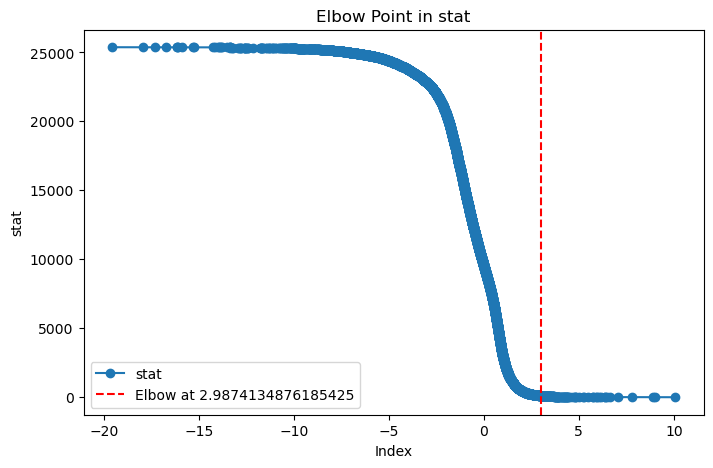

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from kneed import KneeLocator

# Example DataFrame
df = dds
value='stat'
# Step 1: Sort by log2FoldChange (ascending or descending)
df = df.sort_values(by=value, ascending=False).reset_index(drop=True)

# Step 2: Normalize values (optional)
y = np.arange(len(df))  # Indices (gene positions)
x = df[value].values

# Step 3: Apply Kneedle algorithm to find the elbow point
kneedle = KneeLocator(x, y, curve='convex', direction='decreasing')  # Direction depends on sorting
elbow_point = kneedle.elbow

# Plot the log2FoldChange with the detected elbow point
plt.figure(figsize=(8, 5))
plt.plot(x, y, label=value, marker='o')
plt.axvline(elbow_point, color='red', linestyle='--', label=f'Elbow at {elbow_point}')
plt.title(f'Elbow Point in {value}')
plt.xlabel('Index')
plt.ylabel(value)
plt.legend()
plt.show()

In [90]:
### get elbow point
elbow = elbow_point 
#elbow = 15
dds_de = dds[(abs(dds[value])>elbow) & (dds['padj']<0.1)]

dds_de.sort_values(by='log2FoldChange')

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Unnamed: 31302,6.421005e+06,-34.407073,5.652896,-6.086628,1.153136e-09,4.885523e-08
GIMAP1-GIMAP5,1.205429e+07,-27.155545,1.514770,-17.927173,7.236740e-72,9.182699e-68
TMEM187,1.132096e+06,-26.828430,1.370715,-19.572574,2.649545e-85,6.724016e-81
Unnamed: 33813,3.666245e+06,-26.823052,1.667707,-16.083791,3.314586e-58,1.201680e-54
Unnamed: 32081,8.649072e+05,-26.677513,1.995700,-13.367497,9.363873e-41,1.250718e-37
...,...,...,...,...,...,...
NDUFB4,8.215766e+05,9.273909,1.028417,9.017655,1.921589e-19,3.340142e-17
GPX7,3.443875e+04,9.379588,0.930069,10.084828,6.447779e-24,2.045397e-21
RPL12P13,3.999909e+04,10.089088,1.585216,6.364488,1.959421e-10,9.435708e-09
MTCO1P24,8.601578e+04,10.115922,1.432533,7.061565,1.646377e-12,1.090907e-10


In [91]:
top_genes = dds_de.index
top_genes= [item for item in top_genes if "Unnamed" not in item and "NAN" not in item]
len(top_genes)

2427

In [97]:
# Infer enrichment with ora using significant deg


# Run ora
enr_pvals = dc.get_ora_df(
    df=top_genes,
    net=msigdb,
    source='geneset',
    target='genesymbol'
)

enr_pvals.sort_values(by="Combined score", ascending=False).head()

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features
5633,GOBP_POSITIVE_REGULATION_OF_DEFENSE_RESPONSE_T...,14,0.500000,0.000606,1.0,4.270954,31.644260,CYBA;EMILIN1;HAVCR2;KLK7;MMRN2;NOD2;SIGLEC16
20654,LIU_IL13_MEMORY_MODEL_UP,17,0.470588,0.000409,1.0,4.011685,31.297485,CCL26;CCL27;MAP3K10;MAP4K1;MAPK8IP1;MUC5B;PFKF...
2530,GOBP_ANTIBACTERIAL_PEPTIDE_PRODUCTION,9,0.555556,0.002163,1.0,4.777720,29.316994,ELANE;EVPL;KLK7;LGALS4;NOD2
6468,GOBP_REGULATION_OF_ACTIVATION_OF_JANUS_KINASE_...,9,0.555556,0.002163,1.0,4.777720,29.316994,CD300A;IL12B;IL23A;IL23R;SOCS1
1560,DURANTE_ADULT_OLFACTORY_NEUROEPITHELIUM_PLASMA...,21,0.428571,0.000419,1.0,3.650259,28.386108,CYBA;DERL3;IGHG1;IGHG3;IGKC;IGLC2;IGLC3;MZB1;T...


In [93]:
enr_pvals.to_csv(f'/home/amore/work/data/{experiment}_{comparison}_ORA.csv', header=True)

In [95]:
significant_ORA = enr_pvals[(enr_pvals["p-value"] < 0.01) & (enr_pvals["FDR p-value"] < 1)]
significant_ORA.sort_values(by='Combined score')

,Term,Set size,Overlap ratio,p-value,FDR p-value,Odds ratio,Combined score,Features


In [ ]:
dc.plot_dotplot(
    enr_pvals.sort_values('Combined score', ascending=False).head(15),
    x='Combined score',
    y='Term',
    s='Odds ratio',
    c='FDR p-value',
    scale=1.5,
    figsize=(5, 10)
)

### GSEA vs ORA

In [17]:
enr_gsea[enr_gsea['Term'].isin(significant_ORA['Term'])].sort_values(by="NES")

,Term,ES,NES,NOM p-value,FDR p-value,Set size,Tag %,Rank %,Leading edge


In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='wikipathways'],
    source='geneset',
    target='genesymbol',
    set_name='WP_ELECTRON_TRANSPORT_CHAIN_OXPHOS_SYSTEM_IN_MITOCHONDRIA'
)

In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='kegg_pathways'],
    source='geneset',
    target='genesymbol',
    set_name='KEGG_OXIDATIVE_PHOSPHORYLATION'
)

In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='go_biological_process'],
    source='geneset',
    target='genesymbol',
    set_name='GOBP_PROTON_MOTIVE_FORCE_DRIVEN_ATP_SYNTHESIS'
)

In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='go_biological_process'],
    source='geneset',
    target='genesymbol',
    set_name='GOBP_DNA_TEMPLATED_DNA_REPLICATION_MAINTENANCE_OF_FIDELITY'
)



In [ ]:
# Plot
dc.plot_running_score(
    df=dds_de,
    stat='stat',
    net=msigdb[msigdb['collection']=='reactome_pathways'],
    source='geneset',
    target='genesymbol',
    set_name='REACTOME_RESPIRATORY_ELECTRON_TRANSPORT_ATP_SYNTHESIS_BY_CHEMIOSMOTIC_COUPLING_AND_HEAT_PRODUCTION_BY_UNCOUPLING_PROTEINS'
)



In [ ]:
set(msigdb["collection"])